✅ Loaded TikTok | Rows: 134648 | Cols: 79

--- Region Distribution (macro_region) ---
macro_region
( المنطقة الجنوبية ) TikTok Data -  After Cleaning    43051
( المنطقة الوسطى ) TikTok Data -  After Cleaning      30244
( المنطقة الشمالية ) TikTok Data -  After Cleaning    27536
( المنطقة الغربية )TikTok Data -  After Cleaning      23591
( المنطقة الشرقية ) TikTok Data -  After Cleaning     10226
Name: count, dtype: int64

--- Unique Structure Sample (region → subfolder → video) ---
                                            macro_region  \
0      ( المنطقة الجنوبية ) TikTok Data -  After Clea...   
532    ( المنطقة الجنوبية ) TikTok Data -  After Clea...   
808    ( المنطقة الجنوبية ) TikTok Data -  After Clea...   
1497   ( المنطقة الجنوبية ) TikTok Data -  After Clea...   
2713   ( المنطقة الجنوبية ) TikTok Data -  After Clea...   
...                                                  ...   
85132   ( المنطقة الغربية )TikTok Data -  After Cleaning   
86735   ( المنطقة الغربية )TikTok

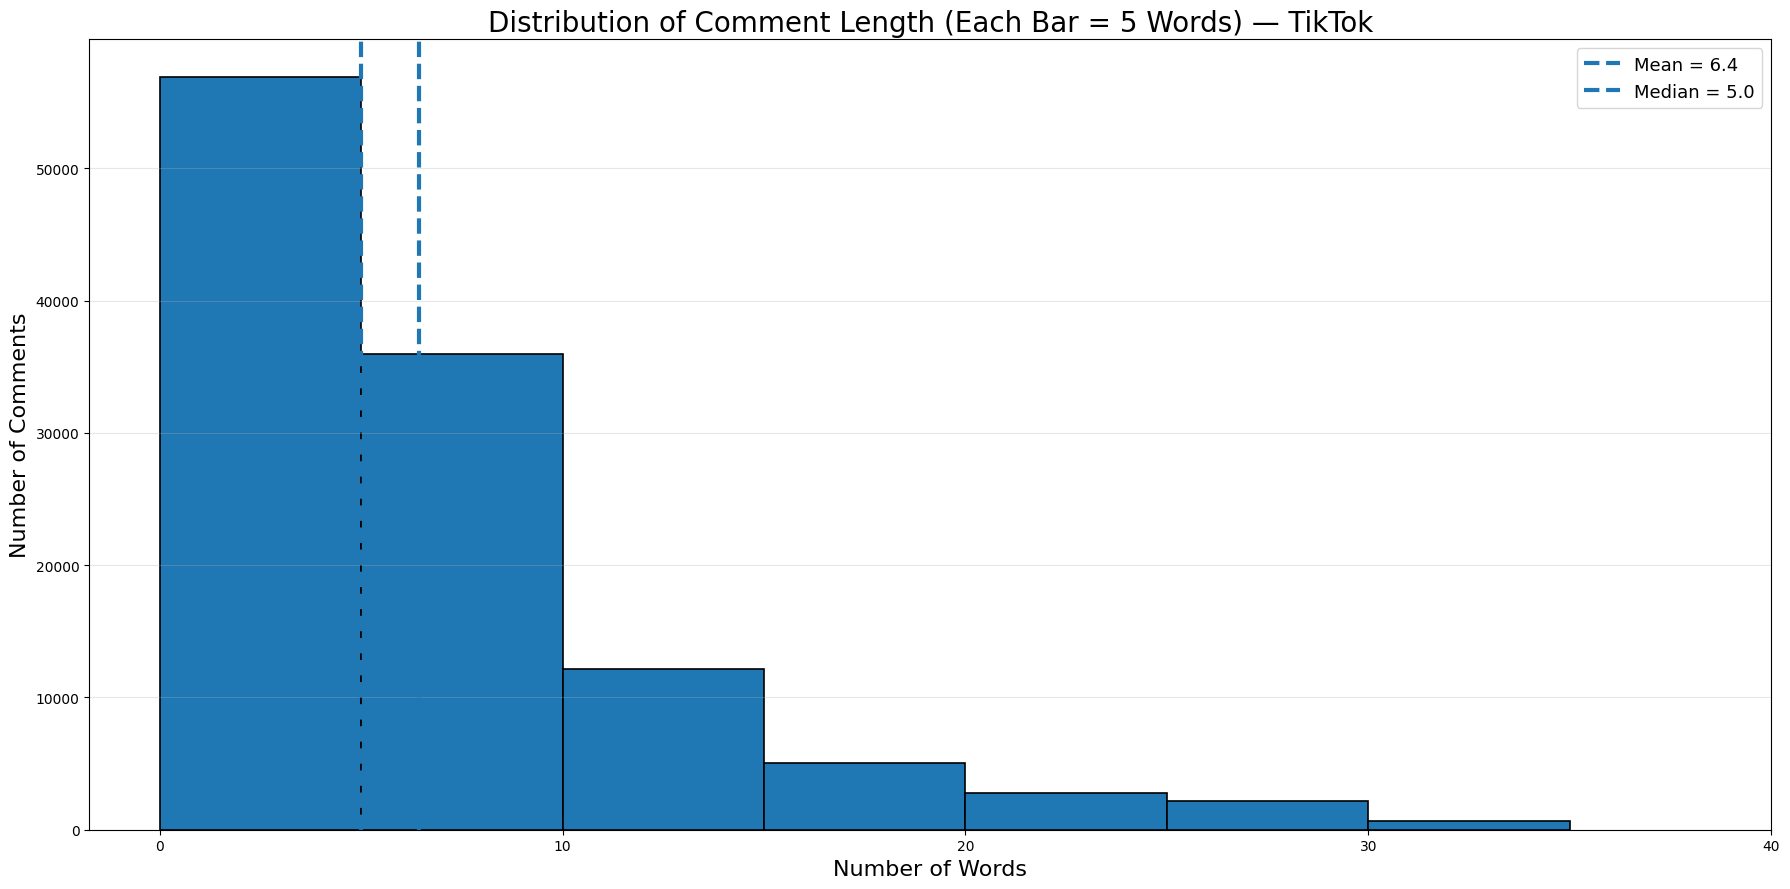

C:\Users\ziyad\AppData\Local\Temp\ipykernel_12460\2800507664.py:160: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ziyad\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


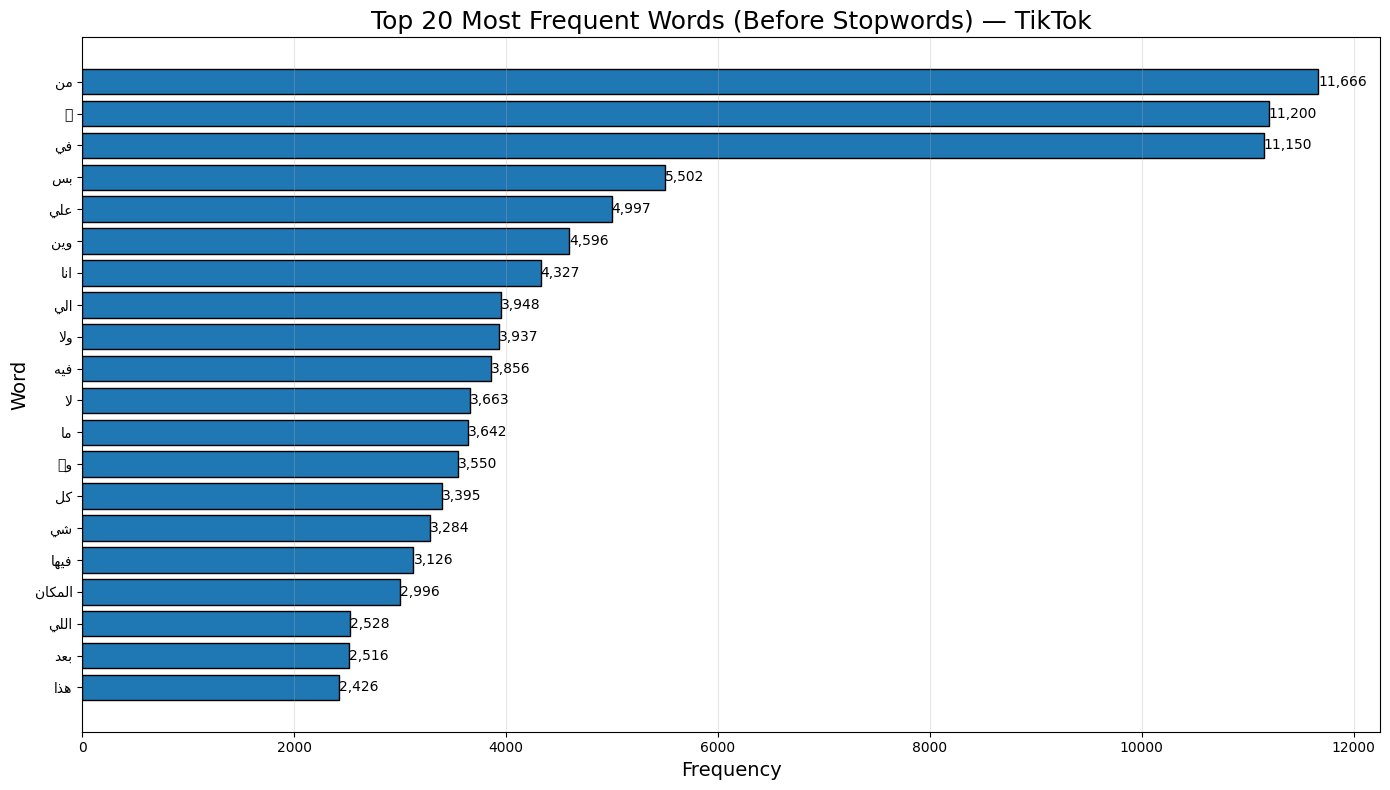

C:\Users\ziyad\AppData\Local\Temp\ipykernel_12460\2800507664.py:182: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ziyad\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


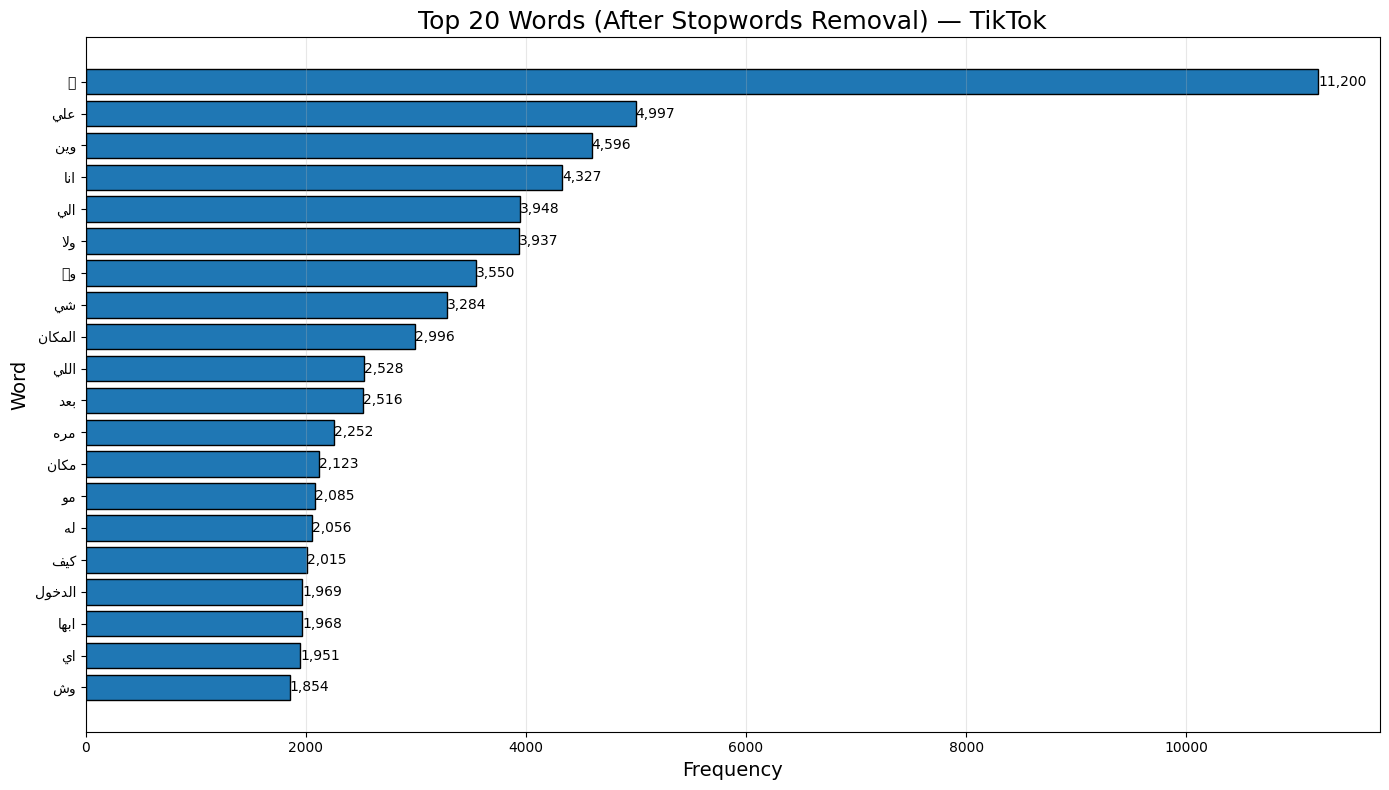

C:\Users\ziyad\AppData\Local\Temp\ipykernel_12460\2800507664.py:210: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ziyad\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


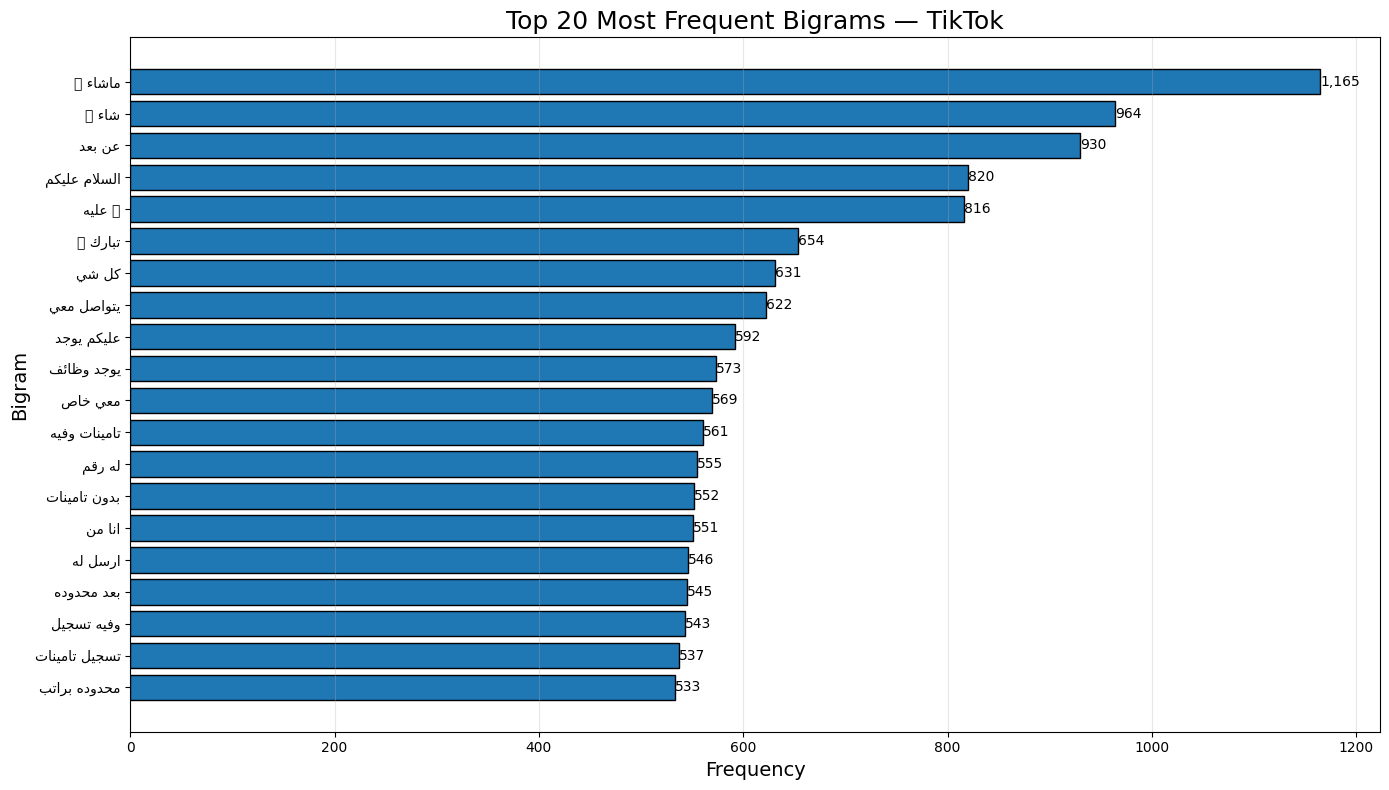


--- Aspect Frequency Table ---
                 frequency
الأسعار               4202
المنظر والطبيعة       2833
المواقف                499
النظافة                481
دورات المياه           417
الخدمات                349
الازدحام               184


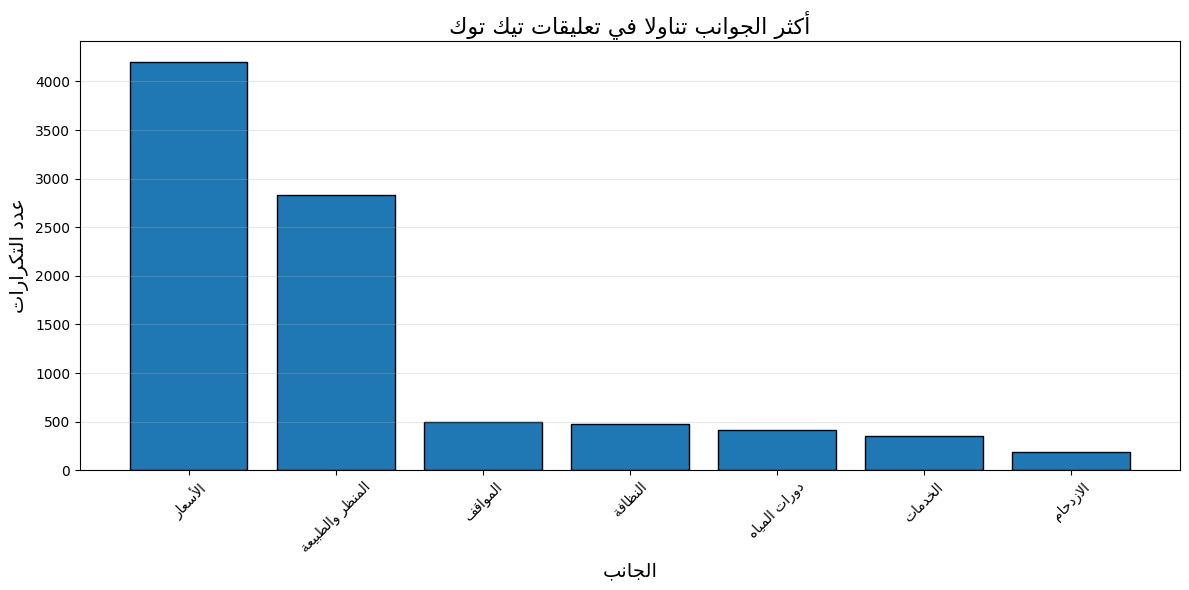


✅ Done: TikTok EDA charts generated (professional token cleaning applied).


: 

In [ ]:
# =========================
# TikTok EDA - Full One Block (Professional)
# Fixes: removes emoji/symbol squares ☐ from Top Words
# =========================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

import arabic_reshaper
from bidi.algorithm import get_display
import re

# ---------- Helpers ----------
def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

# Emojis (common unicode blocks)
EMOJI_RE = re.compile(
    "[" 
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\U00002700-\U000027BF"  # dingbats
    "\U00002600-\U000026FF"  # misc symbols
    "]+",
    flags=re.UNICODE
)

def normalize_word(token: str) -> str:
    # keep only Arabic/English letters (no digits/symbols/emoji)
    return "".join(ch for ch in str(token) if ch.isalpha())

def extract_words_and_emojis(series: pd.Series):
    series = series.dropna().astype(str)
    tokens = series.str.split().explode().dropna()

    # Extract emojis (kept separate)
    emojis = tokens.map(lambda x: "".join(EMOJI_RE.findall(x)))
    emojis = emojis[emojis.str.len() > 0]

    # Clean words (remove symbols/emoji entirely)
    words = tokens.map(normalize_word)
    words = words[(words.str.len() >= 2) & (~words.str.lower().isin(["nan"]))]

    return words, emojis

# =========================
# CONFIG (عدل هنا فقط)
# =========================
ROOT_DIR = Path(r"C:\Users\ziyad\OneDrive\Desktop\EDA\Cleaned Data From TikTok")   # ✅ مسار فولدر TikTok الكبير
FILE_GLOB = "**/*.xlsx"
SOURCE_NAME = "TikTok"
TEXT_COL = "Text_Base"                   # ✅ عدله إذا اسم عمود النص مختلف

# Stopwords (basic set)
AR_STOPWORDS = set("""
و في من على الى إلى عن مع ما لا نعم بس لكن او أو اذا إذا ان إن انه إنها هذا هذه ذلك تلك ثم جدا جدًا مرة مرا
كل كان تكون يكون كانت كانوا يكونون عند عنده عندها عندهم فيه فيها
""".split())

# =========================
# 1) LOAD ALL FILES
# =========================
frames = []
for fp in sorted(ROOT_DIR.glob(FILE_GLOB)):
    try:
        df = pd.read_excel(fp)
        parts = fp.relative_to(ROOT_DIR).parts

        df["source"] = SOURCE_NAME
        df["macro_region"] = parts[0] if len(parts) > 0 else "Unknown"
        df["subfolder"] = parts[1] if len(parts) > 1 else "Unknown"
        df["video_name"] = fp.stem
        df["file_path"] = str(fp)

        frames.append(df)
    except Exception as e:
        print(f"⚠️ Failed: {fp} | {e}")

tt_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print("✅ Loaded TikTok | Rows:", tt_df.shape[0], "| Cols:", tt_df.shape[1])

if tt_df.empty:
    raise ValueError("tt_df is empty. Check ROOT_DIR path and file types (.xlsx).")

if TEXT_COL not in tt_df.columns:
    raise ValueError(f"TEXT_COL='{TEXT_COL}' not found. Available columns: {list(tt_df.columns)}")

# =========================
# 2) STRUCTURE OUTPUTS
# =========================
print("\n--- Region Distribution (macro_region) ---")
print(tt_df["macro_region"].value_counts().head(10))

print("\n--- Unique Structure Sample (region → subfolder → video) ---")
print(tt_df[["macro_region","subfolder","video_name"]].drop_duplicates().head(200))

# =========================
# 3) TEXT LENGTH + CLEAR HIST
# (Trim 99% + each bar = 5 words)
# =========================
tt_df["word_count"] = tt_df[TEXT_COL].dropna().astype(str).str.split().str.len()

upper_limit = tt_df["word_count"].quantile(0.99)
trimmed = tt_df.loc[tt_df["word_count"] <= upper_limit, "word_count"].dropna()

bin_width = 5
bins = np.arange(0, trimmed.max() + bin_width, bin_width)

mean_wc = trimmed.mean()
median_wc = trimmed.median()

plt.figure(figsize=(18,9))
plt.hist(trimmed, bins=bins, edgecolor="black", linewidth=1.2)

plt.axvline(mean_wc, linestyle="--", linewidth=3, label=f"Mean = {mean_wc:.1f}")
plt.axvline(median_wc, linestyle="--", linewidth=3, label=f"Median = {median_wc:.1f}")

plt.title("Distribution of Comment Length (Each Bar = 5 Words) — TikTok", fontsize=20)
plt.xlabel("Number of Words", fontsize=16)
plt.ylabel("Number of Comments", fontsize=16)
plt.xticks(np.arange(0, trimmed.max()+10, 10))
plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

# =========================
# 4) PROFESSIONAL TOKENS (Words + Emojis)
# =========================
tt_words, tt_emojis = extract_words_and_emojis(tt_df[TEXT_COL])

# =========================
# 5) TOP WORDS (Before Stopwords) — NO ☐
# =========================
top_words_df = pd.DataFrame(Counter(tt_words).most_common(20), columns=["word", "frequency"])
top_words_df["word_fixed"] = top_words_df["word"].apply(fix_arabic)

plt.figure(figsize=(14,8))
bars = plt.barh(top_words_df["word_fixed"], top_words_df["frequency"], edgecolor="black")
plt.gca().invert_yaxis()
for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y() + bar.get_height()/2, f"{int(w):,}", va="center")

plt.title("Top 20 Most Frequent Words (Before Stopwords) — TikTok", fontsize=18)
plt.xlabel("Frequency", fontsize=14)
plt.ylabel("Word", fontsize=14)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 6) TOP WORDS (After Stopwords) — NO ☐
# =========================
tt_words_clean = tt_words[~tt_words.isin(AR_STOPWORDS)]

top_words_clean_df = pd.DataFrame(Counter(tt_words_clean).most_common(20), columns=["word", "frequency"])
top_words_clean_df["word_fixed"] = top_words_clean_df["word"].apply(fix_arabic)

plt.figure(figsize=(14,8))
bars = plt.barh(top_words_clean_df["word_fixed"], top_words_clean_df["frequency"], edgecolor="black")
plt.gca().invert_yaxis()
for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y() + bar.get_height()/2, f"{int(w):,}", va="center")

plt.title("Top 20 Words (After Stopwords Removal) — TikTok", fontsize=18)
plt.xlabel("Frequency", fontsize=14)
plt.ylabel("Word", fontsize=14)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 7) TOP BIGRAMS
# =========================
texts = tt_df[TEXT_COL].dropna().astype(str)

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(texts)

bigrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

bigrams_df = pd.DataFrame({"bigram": bigrams, "frequency": counts}).sort_values("frequency", ascending=False)
bigrams_df["bigram_fixed"] = bigrams_df["bigram"].apply(fix_arabic)

plt.figure(figsize=(14,8))
bars = plt.barh(bigrams_df["bigram_fixed"], bigrams_df["frequency"], edgecolor="black")
plt.gca().invert_yaxis()
for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y() + bar.get_height()/2, f"{int(w):,}", va="center")

plt.title("Top 20 Most Frequent Bigrams — TikTok", fontsize=18)
plt.xlabel("Frequency", fontsize=14)
plt.ylabel("Bigram", fontsize=14)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 8) ASPECT ANALYSIS + Arabic-safe plot
# =========================
ASPECTS = {
    "المنظر والطبيعة": ["منظر", "اطلالة", "طبيعة", "جميل", "روعة"],
    "الأسعار": ["سعر", "اسعار", "غالي", "رخيص", "مبالغ"],
    "النظافة": ["نظيف", "نظافة", "وسخ", "قذر"],
    "الخدمات": ["خدمة", "تعامل", "موظف", "استقبال"],
    "دورات المياه": ["دورات", "حمام", "مياه"],
    "المواقف": ["موقف", "مواقف", "سيارات"],
    "الازدحام": ["زحام", "ازدحام", "مزدحم", "هدوء"]
}

s = tt_df[TEXT_COL].dropna().astype(str)
aspect_counts = {asp: s.apply(lambda x: any(k in x for k in keys)).sum()
                 for asp, keys in ASPECTS.items()}

aspect_df = pd.DataFrame.from_dict(aspect_counts, orient="index", columns=["frequency"])\
            .sort_values("frequency", ascending=False)

print("\n--- Aspect Frequency Table ---")
print(aspect_df)

aspect_df_fixed = aspect_df.copy()
aspect_df_fixed.index = aspect_df_fixed.index.map(fix_arabic)

plt.figure(figsize=(12,6))
plt.bar(aspect_df_fixed.index, aspect_df_fixed["frequency"], edgecolor="black")
plt.title(fix_arabic("أكثر الجوانب تناولاً في تعليقات تيك توك"), fontsize=16)
plt.xlabel(fix_arabic("الجانب"), fontsize=14)
plt.ylabel(fix_arabic("عدد التكرارات"), fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 9) OPTIONAL: Top Emojis (separate analysis)
# =========================
top_emojis_df = pd.DataFrame(Counter(tt_emojis).most_common(15), columns=["emoji", "frequency"])

if not top_emojis_df.empty:
    plt.figure(figsize=(12,6))
    bars = plt.barh(top_emojis_df["emoji"], top_emojis_df["frequency"], edgecolor="black")
    plt.gca().invert_yaxis()
    for bar in bars:
        w = bar.get_width()
        plt.text(w, bar.get_y() + bar.get_height()/2, f"{int(w):,}", va="center")
    plt.title("Top 15 Emojis — TikTok", fontsize=18)
    plt.xlabel("Frequency", fontsize=14)
    plt.ylabel("Emoji", fontsize=14)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n✅ Done: TikTok EDA charts generated (professional token cleaning applied).")
